In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully!')

Mounted at /content/drive
Google Drive mounted successfully!


# Setup

In [2]:
!pip install catboost lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 20.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from lime import lime_tabular
import shap

print('All libraries loaded.')

All libraries loaded.


# Constants

In [4]:
# Constants — edit here to reconfigure the experiment
DATASET_PATH  = '/content/drive/MyDrive/US/US_Accidents_Sampled_Merged.csv'
FIG_DIR       = '/content/drive/MyDrive/US/figure/'
RANDOM_STATE  = 42
TARGET_COL    = 'Severity'
TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
N_FOLDS       = 5
TOP_K_WIND    = 20   # top-K categories cho Wind_Direction trước OHE
TOP_K_WEATHER = 20   # top-K categories cho Weather_Condition trước OHE

import os
os.makedirs(FIG_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)
print('Constants set.')

Constants set.


# 1. Load Data

In [5]:
print('=' * 60)
print('LOADING DATA')
print('=' * 60)

df = pd.read_csv(DATASET_PATH, low_memory=False)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Shape   : {df.shape}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nSeverity distribution (original labels):')
print(df[TARGET_COL].value_counts().sort_index())

# Binary label: Severity 4 → 1 (nghiêm trọng), Severity 1/2/3 → 0
df['label'] = (df[TARGET_COL] == 4).astype(int)
print(f'\nBinary label distribution:')
print(df['label'].value_counts().sort_index())
print(f'  0 (Severity 1/2/3): {(df["label"]==0).sum():,}')
print(f'  1 (Severity 4)    : {(df["label"]==1).sum():,}')

LOADING DATA
Shape   : (409421, 46)
Memory  : 540.9 MB

Severity distribution (original labels):
Severity
1     13773
2    133352
3     57586
4    204710
Name: count, dtype: int64

Binary label distribution:
label
0    204711
1    204710
Name: count, dtype: int64
  0 (Severity 1/2/3): 204,711
  1 (Severity 4)    : 204,710


# 2. EDA — Severity 4 Profile

Compare Severity 4 accidents with the remaining severity groups based on key features.

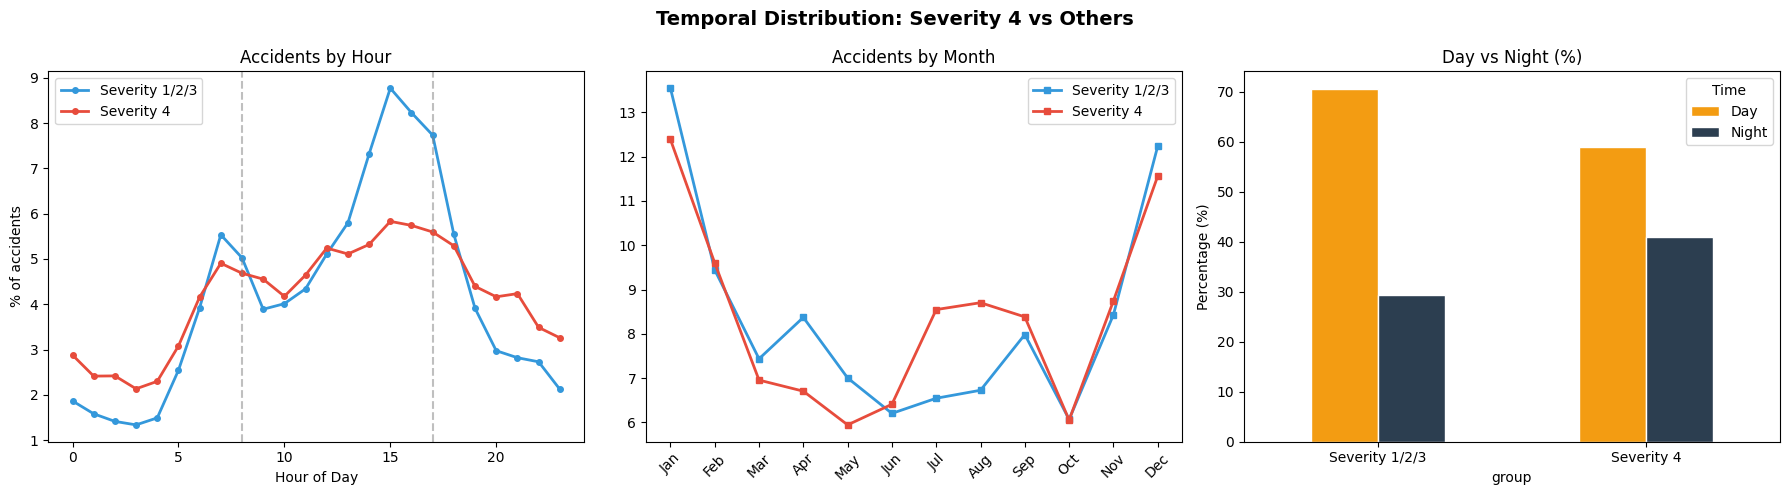

Figure 1 saved.


In [6]:
df_eda = df.copy()
df_eda['Start_Time'] = pd.to_datetime(df_eda['Start_Time'], errors='coerce')
df_eda['hour']       = df_eda['Start_Time'].dt.hour
df_eda['month']      = df_eda['Start_Time'].dt.month
df_eda['group']      = df_eda['label'].map({0: 'Severity 1/2/3', 1: 'Severity 4'})

COLORS = {'Severity 1/2/3': '#3498db', 'Severity 4': '#e74c3c'}

# ── Figure 1: Temporal Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Temporal Distribution: Severity 4 vs Others', fontsize=14, fontweight='bold')

# Hour
for grp, color in COLORS.items():
    sub = df_eda[df_eda['group'] == grp]['hour'].value_counts().sort_index()
    sub_pct = sub / sub.sum() * 100
    axes[0].plot(sub_pct.index, sub_pct.values, marker='o', lw=2,
                 color=color, label=grp, markersize=4)
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('% of accidents')
axes[0].set_title('Accidents by Hour'); axes[0].legend()
axes[0].axvline(8,  ls='--', color='gray', alpha=0.5)
axes[0].axvline(17, ls='--', color='gray', alpha=0.5)

# Month
month_lbls = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for grp, color in COLORS.items():
    sub = df_eda[df_eda['group'] == grp]['month'].value_counts().sort_index()
    sub_pct = sub / sub.sum() * 100
    axes[1].plot(sub_pct.index, sub_pct.values, marker='s', lw=2,
                 color=color, label=grp, markersize=4)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_lbls, rotation=45)
axes[1].set_title('Accidents by Month'); axes[1].legend()

# Day/Night
if 'Sunrise_Sunset' in df_eda.columns:
    cross = pd.crosstab(df_eda['group'], df_eda['Sunrise_Sunset'])
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.plot(kind='bar', ax=axes[2], color=['#f39c12', '#2c3e50'],
                   rot=0, edgecolor='white')
    axes[2].set_title('Day vs Night (%)')
    axes[2].set_ylabel('Percentage (%)')
    axes[2].legend(title='Time')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_temporal_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

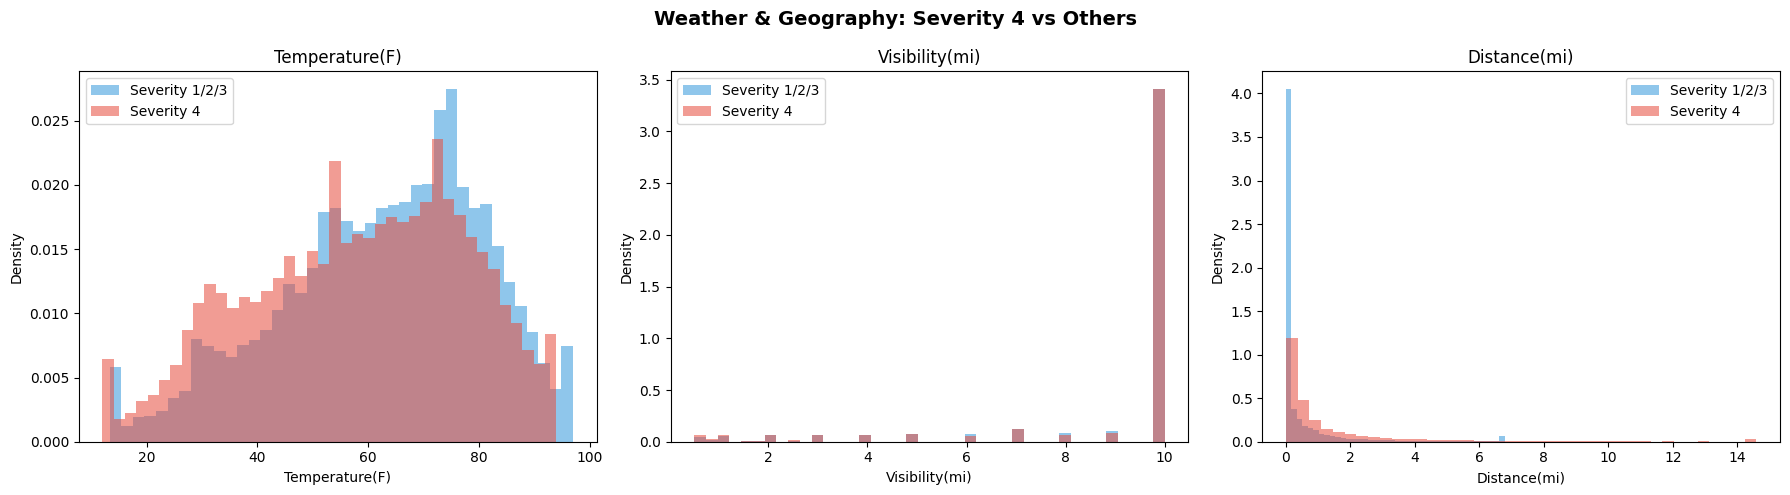

Figure 2 saved.


In [7]:
# ── Figure 2: Weather & Geography Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Weather & Geography: Severity 4 vs Others', fontsize=14, fontweight='bold')

weather_feats = ['Temperature(F)', 'Visibility(mi)', 'Distance(mi)']
for ax, feat in zip(axes, weather_feats):
    if feat not in df_eda.columns:
        continue
    for grp, color in COLORS.items():
        vals = df_eda[df_eda['group'] == grp][feat].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))  # clip outliers
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=grp, density=True)
    ax.set_title(feat); ax.set_xlabel(feat); ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_weather_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

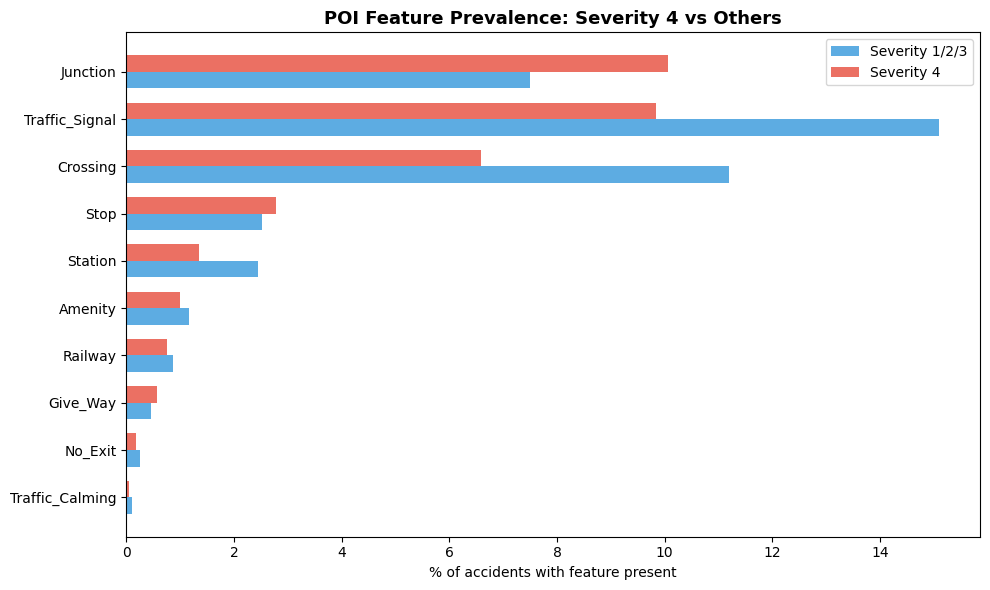

Figure 3 saved.


In [8]:
# ── Figure 3: POI Feature Prevalence ─────────────────────────────────────────
poi_cols = ['Amenity', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
            'Railway', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal']
poi_cols = [c for c in poi_cols if c in df_eda.columns]

poi_data = []
for grp in ['Severity 1/2/3', 'Severity 4']:
    sub = df_eda[df_eda['group'] == grp]
    means = sub[poi_cols].apply(lambda c: ((c == True) | (c == 1)).mean() * 100)
    poi_data.append(means.rename(grp))
poi_df = pd.DataFrame(poi_data).T.sort_values('Severity 4', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(poi_df))
w = 0.35
ax.barh(x - w/2, poi_df['Severity 1/2/3'], w, color='#3498db',
        alpha=0.8, label='Severity 1/2/3')
ax.barh(x + w/2, poi_df['Severity 4'],     w, color='#e74c3c',
        alpha=0.8, label='Severity 4')
ax.set_yticks(x); ax.set_yticklabels(poi_df.index)
ax.set_xlabel('% of accidents with feature present')
ax.set_title('POI Feature Prevalence: Severity 4 vs Others', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_poi_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

# 3. Feature Engineering

In [9]:
# ── Time features ─────────────────────────────────────────────────────────────
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['hour']       = df['Start_Time'].dt.hour
df['month']      = df['Start_Time'].dt.month
df['dayofweek']  = df['Start_Time'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['is_rush']    = df['hour'].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

print('Time features created:', ['hour', 'month', 'dayofweek', 'is_weekend', 'is_rush'])

Time features created: ['hour', 'month', 'dayofweek', 'is_weekend', 'is_rush']


In [10]:
# ── Drop columns ──────────────────────────────────────────────────────────────
# Giữ lại: Distance(mi), month, dayofweek
# (đây là top features trong SHAP analysis)
DROP_COLS = [
    'ID', 'Description', 'Street', 'City', 'State', 'County', 'Zipcode',
    'Airport_Code', 'Weather_Timestamp',
    'End_Lat', 'End_Lng',
    'Start_Lat', 'Start_Lng',
    'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
    'Wind_Chill(F)', 'Country', 'Source',
    'Start_Time', 'End_Time',
    TARGET_COL,          # original label
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
print(f'Shape after drop: {df.shape}')

Shape after drop: (409421, 30)


In [11]:
# ── Sunrise_Sunset → is_night ─────────────────────────────────────────────────
if 'Sunrise_Sunset' in df.columns:
    df['is_night'] = (df['Sunrise_Sunset'].str.strip().str.lower() == 'night').astype(int)
    df.drop(columns=['Sunrise_Sunset'], inplace=True)

# ── Boolean → int ─────────────────────────────────────────────────────────────
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

# ── Fill numeric NaN ─────────────────────────────────────────────────────────
df = df[df['label'].notna()]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f'String cols before OHE: {df.select_dtypes("object").columns.tolist()}')

String cols before OHE: ['Timezone', 'Wind_Direction', 'Weather_Condition']


# 4. Train / Val / Test Split

The OHE encoder is fitted only on the training set to prevent data leakage.

In [12]:
TARGET_BINARY = 'label'
OHE_COLS      = [c for c in ['Wind_Direction', 'Weather_Condition', 'Timezone']
                 if c in df.columns]

y = df[TARGET_BINARY].values.astype(int)
X_raw = df.drop(columns=[TARGET_BINARY])

# Stratified split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE,
    random_state=RANDOM_STATE, stratify=y_trainval)

# ── OHE: group rare categories then fit on train only ────────────────────────
for col in OHE_COLS:
    top_k = TOP_K_WIND if col == 'Wind_Direction' else TOP_K_WEATHER
    top_cats = X_train[col].astype(str).value_counts().nlargest(top_k).index
    for split in [X_train, X_val, X_test]:
        split[col] = split[col].astype(str).where(
            split[col].astype(str).isin(top_cats), other='Other')

if OHE_COLS:
    try:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
    ohe.fit(X_train[OHE_COLS].astype(str))
    ohe_names = ohe.get_feature_names_out(OHE_COLS)

    def apply_ohe(data):
        enc = ohe.transform(data[OHE_COLS].astype(str))
        df_enc = pd.DataFrame(enc, columns=ohe_names, index=data.index)
        return pd.concat([data.drop(columns=OHE_COLS), df_enc], axis=1)

    X_train = apply_ohe(X_train)
    X_val   = apply_ohe(X_val)
    X_test  = apply_ohe(X_test)

feature_names = X_train.columns.tolist()

X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)

# Scale cho LR
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_np)
X_val_sc   = scaler.transform(X_val_np)
X_test_sc  = scaler.transform(X_test_np)

print(f'Train : {X_train_np.shape} | Val: {X_val_np.shape} | Test: {X_test_np.shape}')
print(f'Features: {len(feature_names)}')
print(f'Label balance — Train: {np.bincount(y_train)} | Test: {np.bincount(y_test)}')

Train : (295805, 73) | Val: (52202, 73) | Test: (61414, 73)
Features: 73
Label balance — Train: [147903 147902] | Test: [30707 30707]


# 5. Metrics Helper

In [13]:
results = []

def evaluate(name, y_true, y_pred, y_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_c = f1_score(y_true, y_pred, pos_label=1, zero_division=0)   # F1 cho class Sev4
    auc  = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  F1 (weighted)     : {f1:.4f}")
    print(f"  F1 (Severity 4)   : {f1_c:.4f}")
    if auc: print(f"  AUC-ROC           : {auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=['Non-critical (0)', 'Severity 4 (1)'],
                                zero_division=0))
    row = {'model': name, 'accuracy': acc, 'f1_weighted': f1,
           'f1_sev4': f1_c, 'auc': auc}
    results.append(row)
    return row

# 6. Models
## Logistic Regression (Baseline)

In [14]:
print('=' * 60)
print('MODEL: Logistic Regression')
print('=' * 60)

lr_model = LogisticRegression(
    max_iter=1000, C=1.0, solver='saga', n_jobs=-1, random_state=RANDOM_STATE
)
lr_model.fit(X_train_sc, y_train)
y_pred_lr   = lr_model.predict(X_test_sc)
y_proba_lr  = lr_model.predict_proba(X_test_sc)[:, 1]
evaluate('Logistic Regression', y_test, y_pred_lr, y_proba_lr)

MODEL: Logistic Regression

───────────────────────────────────────────────────────
  Logistic Regression
  Accuracy          : 0.6635
  F1 (weighted)     : 0.6634
  F1 (Severity 4)   : 0.6597
  AUC-ROC           : 0.7170
                  precision    recall  f1-score   support

Non-critical (0)       0.66      0.67      0.67     30707
  Severity 4 (1)       0.67      0.65      0.66     30707

        accuracy                           0.66     61414
       macro avg       0.66      0.66      0.66     61414
    weighted avg       0.66      0.66      0.66     61414



{'model': 'Logistic Regression',
 'accuracy': 0.6634643566613476,
 'f1_weighted': 0.663422849922859,
 'f1_sev4': 0.6596851742079958,
 'auc': np.float64(0.7169717767814219)}

## Random Forest

In [15]:
print('=' * 60)
print('MODEL: Random Forest')
print('=' * 60)

rf_model = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train_np, y_train)
y_pred_rf  = rf_model.predict(X_test_np)
y_proba_rf = rf_model.predict_proba(X_test_np)[:, 1]
evaluate('Random Forest', y_test, y_pred_rf, y_proba_rf)

MODEL: Random Forest

───────────────────────────────────────────────────────
  Random Forest
  Accuracy          : 0.8022
  F1 (weighted)     : 0.8010
  F1 (Severity 4)   : 0.8164
  AUC-ROC           : 0.8756
                  precision    recall  f1-score   support

Non-critical (0)       0.86      0.73      0.79     30707
  Severity 4 (1)       0.76      0.88      0.82     30707

        accuracy                           0.80     61414
       macro avg       0.81      0.80      0.80     61414
    weighted avg       0.81      0.80      0.80     61414



{'model': 'Random Forest',
 'accuracy': 0.8022275051291237,
 'f1_weighted': 0.8010413234461236,
 'f1_sev4': 0.8164036519741218,
 'auc': np.float64(0.8755603351393655)}

## XGBoost

In [16]:
print('=' * 60)
print('MODEL: XGBoost')
print('=' * 60)

xgb_model = xgb.XGBClassifier(
    n_estimators=2000, max_depth=6, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', tree_method='hist',
    n_jobs=-1, random_state=RANDOM_STATE, early_stopping_rounds=50,
)
xgb_model.fit(X_train_np, y_train,
              eval_set=[(X_val_np, y_val)], verbose=100)
y_pred_xgb  = xgb_model.predict(X_test_np)
y_proba_xgb = xgb_model.predict_proba(X_test_np)[:, 1]
evaluate('XGBoost', y_test, y_pred_xgb, y_proba_xgb)

MODEL: XGBoost
[0]	validation_0-logloss:0.69137
[100]	validation_0-logloss:0.49129
[200]	validation_0-logloss:0.47193
[300]	validation_0-logloss:0.46617
[400]	validation_0-logloss:0.46328
[500]	validation_0-logloss:0.46132
[600]	validation_0-logloss:0.45981
[700]	validation_0-logloss:0.45843
[800]	validation_0-logloss:0.45720
[900]	validation_0-logloss:0.45624
[1000]	validation_0-logloss:0.45536
[1100]	validation_0-logloss:0.45448
[1200]	validation_0-logloss:0.45374
[1300]	validation_0-logloss:0.45303
[1400]	validation_0-logloss:0.45245
[1500]	validation_0-logloss:0.45194
[1600]	validation_0-logloss:0.45144
[1700]	validation_0-logloss:0.45105
[1800]	validation_0-logloss:0.45065
[1900]	validation_0-logloss:0.45027
[1999]	validation_0-logloss:0.44997

───────────────────────────────────────────────────────
  XGBoost
  Accuracy          : 0.7950
  F1 (weighted)     : 0.7938
  F1 (Severity 4)   : 0.8093
  AUC-ROC           : 0.8646
                  precision    recall  f1-score   support


{'model': 'XGBoost',
 'accuracy': 0.7949816002865796,
 'f1_weighted': 0.7938203537355438,
 'f1_sev4': 0.8092937309725399,
 'auc': np.float64(0.8646462712229956)}

## LightGBM

In [17]:
print('=' * 60)
print('MODEL: LightGBM')
print('=' * 60)

lgb_model = lgb.LGBMClassifier(
    n_estimators=2000, num_leaves=63, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
)
lgb_model.fit(
    X_train_np, y_train,
    eval_set=[(X_val_np, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
y_pred_lgb  = lgb_model.predict(X_test_np)
y_proba_lgb = lgb_model.predict_proba(X_test_np)[:, 1]
evaluate('LightGBM', y_test, y_pred_lgb, y_proba_lgb)

MODEL: LightGBM
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.483991
[200]	valid_0's binary_logloss: 0.460699
[300]	valid_0's binary_logloss: 0.455355
[400]	valid_0's binary_logloss: 0.453069
[500]	valid_0's binary_logloss: 0.452133
[600]	valid_0's binary_logloss: 0.451413
[700]	valid_0's binary_logloss: 0.450757
[800]	valid_0's binary_logloss: 0.450162
[900]	valid_0's binary_logloss: 0.449623
[1000]	valid_0's binary_logloss: 0.449033
[1100]	valid_0's binary_logloss: 0.448487
[1200]	valid_0's binary_logloss: 0.448068
[1300]	valid_0's binary_logloss: 0.447448
[1400]	valid_0's binary_logloss: 0.44701
[1500]	valid_0's binary_logloss: 0.446685
[1600]	valid_0's binary_logloss: 0.446375
[1700]	valid_0's binary_logloss: 0.446066
[1800]	valid_0's binary_logloss: 0.445737
[1900]	valid_0's binary_logloss: 0.44543
[2000]	valid_0's binary_logloss: 0.445032
Did not meet early stopping. Best iteration is:
[2000]	valid_0's binary_logloss: 0.445032

───

{'model': 'LightGBM',
 'accuracy': 0.7963819324583971,
 'f1_weighted': 0.7951961777705261,
 'f1_sev4': 0.8107797297501778,
 'auc': np.float64(0.867331625659733)}

## CatBoost

In [18]:
print('=' * 60)
print('MODEL: CatBoost')
print('=' * 60)

cat_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.045,
    loss_function='Logloss', eval_metric='Accuracy',
    random_seed=RANDOM_STATE, verbose=55, early_stopping_rounds=40,
)
cat_model.fit(X_train_np, y_train, eval_set=(X_val_np, y_val))
y_pred_cat  = cat_model.predict(X_test_np).flatten()
y_proba_cat = cat_model.predict_proba(X_test_np)[:, 1]
evaluate('CatBoost', y_test, y_pred_cat, y_proba_cat)

MODEL: CatBoost
0:	learn: 0.7675022	test: 0.7669438	best: 0.7669438 (0)	total: 118ms	remaining: 58.7s
55:	learn: 0.7727219	test: 0.7719053	best: 0.7719244 (54)	total: 5.5s	remaining: 43.6s
110:	learn: 0.7772249	test: 0.7756408	best: 0.7756408 (110)	total: 9.17s	remaining: 32.1s
165:	learn: 0.7801322	test: 0.7780928	best: 0.7780928 (165)	total: 12.8s	remaining: 25.7s
220:	learn: 0.7828400	test: 0.7805257	best: 0.7805257 (220)	total: 18s	remaining: 22.7s
275:	learn: 0.7843613	test: 0.7817133	best: 0.7817133 (274)	total: 21.6s	remaining: 17.5s
330:	learn: 0.7861463	test: 0.7831501	best: 0.7831692 (317)	total: 25.2s	remaining: 12.9s
385:	learn: 0.7879008	test: 0.7847209	best: 0.7847209 (385)	total: 29.4s	remaining: 8.69s
440:	learn: 0.7890130	test: 0.7858128	best: 0.7858894 (435)	total: 34.1s	remaining: 4.57s
Stopped by overfitting detector  (40 iterations wait)

bestTest = 0.7864449638
bestIteration = 451

Shrink model to first 452 iterations.

────────────────────────────────────────────

{'model': 'CatBoost',
 'accuracy': 0.78827303220764,
 'f1_weighted': 0.7865137934089323,
 'f1_sev4': 0.8058935049037902,
 'auc': np.float64(0.857263150051686)}

## MLP (Multi-Layer Perceptron)

In [20]:
print('=' * 60)
print('MODEL: MLP (Multi-Layer Perceptron)')
print('=' * 60)

# MLP requires scaled input — dùng X_train_sc / X_test_sc (cùng scaler với LR)
# Architecture: 2 hidden layers (256, 128) với ReLU + early stopping nội bộ
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    batch_size=1024,
    random_state=RANDOM_STATE,
    verbose=False,
)
mlp_model.fit(X_train_sc, y_train)

y_pred_mlp  = mlp_model.predict(X_test_sc)
y_proba_mlp = mlp_model.predict_proba(X_test_sc)[:, 1]
evaluate('MLP', y_test, y_pred_mlp, y_proba_mlp)

# best_validation_score_ available when early_stopping=True; best_loss_ only when False
val_score = getattr(mlp_model, 'best_validation_score_', None)
if val_score is not None:
    print(f'\nBest validation score : {val_score:.4f}')
print(f'Iterations ran        : {mlp_model.n_iter_}')

MODEL: MLP (Multi-Layer Perceptron)

───────────────────────────────────────────────────────
  MLP
  Accuracy          : 0.7687
  F1 (weighted)     : 0.7684
  F1 (Severity 4)   : 0.7760
  AUC-ROC           : 0.8367
                  precision    recall  f1-score   support

Non-critical (0)       0.79      0.74      0.76     30707
  Severity 4 (1)       0.75      0.80      0.78     30707

        accuracy                           0.77     61414
       macro avg       0.77      0.77      0.77     61414
    weighted avg       0.77      0.77      0.77     61414


Best validation score : 0.7696
Iterations ran        : 41


# 7. Results Summary

RESULTS SUMMARY
              model  accuracy  f1_weighted  f1_sev4      auc
      Random Forest  0.802228     0.801041 0.816404 0.875560
           LightGBM  0.796382     0.795196 0.810780 0.867332
            XGBoost  0.794982     0.793820 0.809294 0.864646
           CatBoost  0.788273     0.786514 0.805894 0.857263
                MLP  0.768652     0.768402 0.776012 0.836705
                MLP  0.768652     0.768402 0.776012 0.836705
Logistic Regression  0.663464     0.663423 0.659685 0.716972


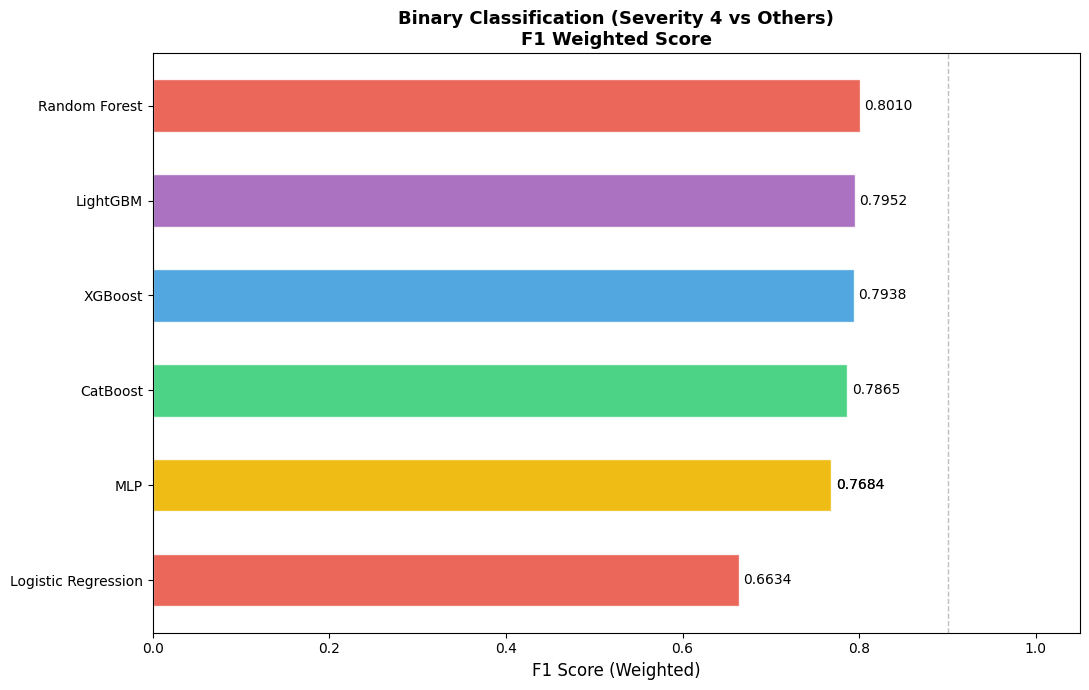

In [21]:
print('=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)

df_results = pd.DataFrame(results).sort_values('f1_weighted', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
palette = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
bars = ax.barh(
    df_results['model'][::-1], df_results['f1_weighted'][::-1],
    color=palette[:len(df_results)], alpha=0.85, edgecolor='white', height=0.55
)
ax.set_xlabel('F1 Score (Weighted)', fontsize=12)
ax.set_title('Binary Classification (Severity 4 vs Others)\nF1 Weighted Score', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(0.9, ls='--', color='gray', alpha=0.5, lw=1)
for bar, val in zip(bars, df_results['f1_weighted'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

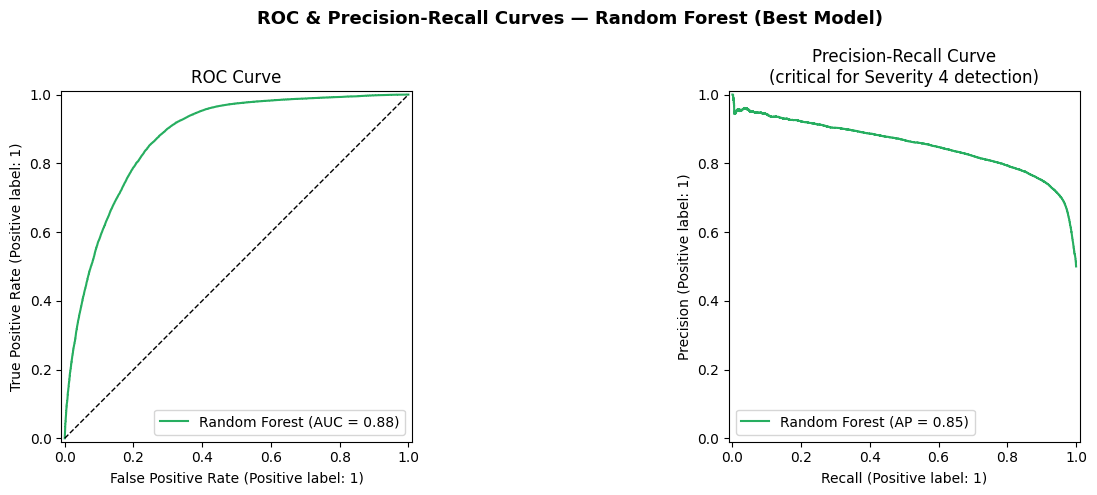

In [22]:
# ── ROC & Precision-Recall Curves — Random Forest (Best Model) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC & Precision-Recall Curves — Random Forest (Best Model)', fontsize=13, fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0],
                                  name='Random Forest', color='#27ae60')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1],
                                         name='Random Forest', color='#27ae60')
axes[1].set_title('Precision-Recall Curve\n(critical for Severity 4 detection)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. TreeSHAP Explanation (LightGBM)

Explain which factors contribute to predicting an accident as Severity 4.

In [23]:
print('=' * 60)
print('TreeSHAP — LightGBM')
print('=' * 60)

BOOL_FEATS = [f for f in feature_names if f in [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop', 'is_night', 'is_weekend', 'is_rush'
]]
CONT_FEATS = [f for f in feature_names
              if f not in BOOL_FEATS and not any(
                  f.startswith(c + '_') for c in ['Wind_Direction', 'Weather_Condition', 'Timezone']
              )]

# Sample cân bằng 300 Sev4 / 300 non-critical
np.random.seed(RANDOM_STATE)
idx_pos = np.random.choice(np.where(y_test == 1)[0], 300, replace=False)
idx_neg = np.random.choice(np.where(y_test == 0)[0], 300, replace=False)
shap_idx = np.concatenate([idx_pos, idx_neg])
X_shap   = X_test_np[shap_idx]
y_shap   = y_test[shap_idx]

explainer_shap = shap.TreeExplainer(lgb_model)
raw_sv = explainer_shap.shap_values(X_shap)
# LightGBM binary: raw_sv có thể là list[2] hoặc array 2D
sv = raw_sv[1] if isinstance(raw_sv, list) else raw_sv
mean_abs = np.abs(sv).mean(axis=0)

print(f'SHAP computed on {len(X_shap)} samples ({(y_shap==1).sum()} Sev4 / {(y_shap==0).sum()} Others)')

TreeSHAP — LightGBM
SHAP computed on 600 samples (300 Sev4 / 300 Others)


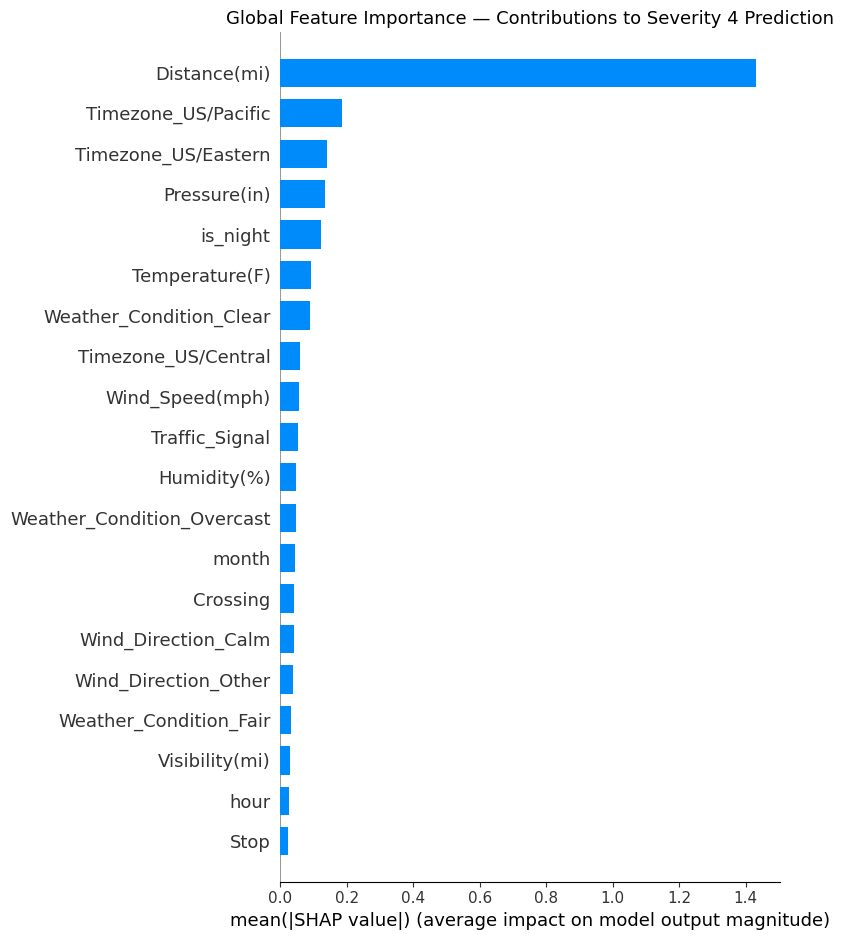

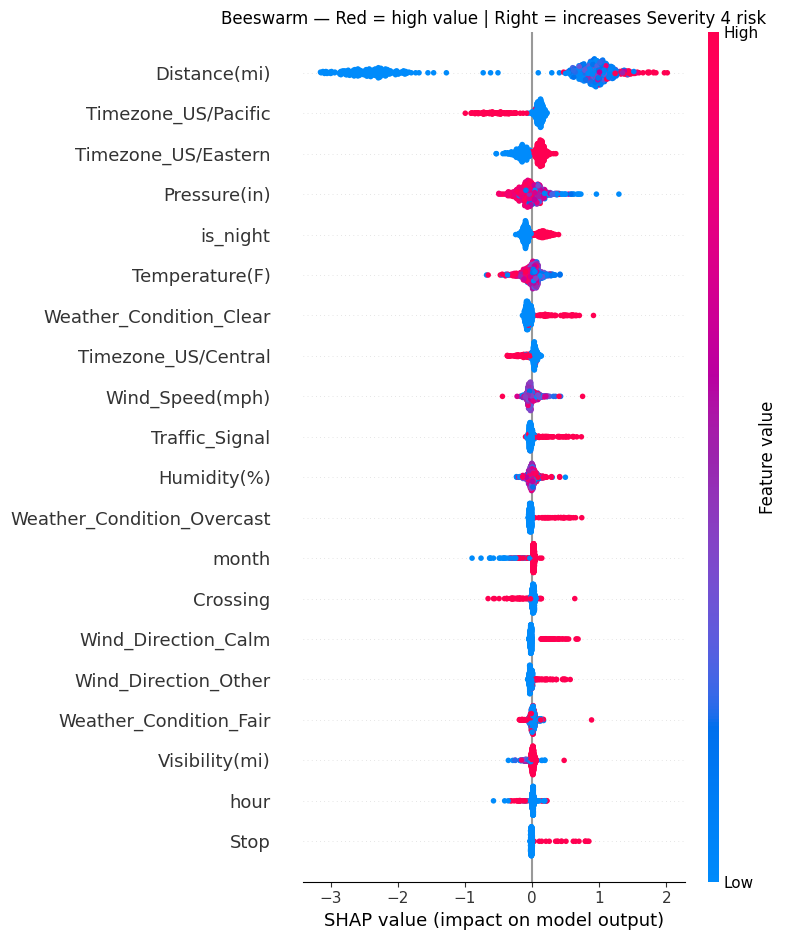

In [24]:
# ── Plot 1: Global Bar — top 20 features ─────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=20)
plt.title('Global Feature Importance — Contributions to Severity 4 Prediction', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Beeswarm ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_shap, feature_names=feature_names,
                  plot_type='dot', show=False, max_display=20)
plt.title('Beeswarm — Red = high value | Right = increases Severity 4 risk', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

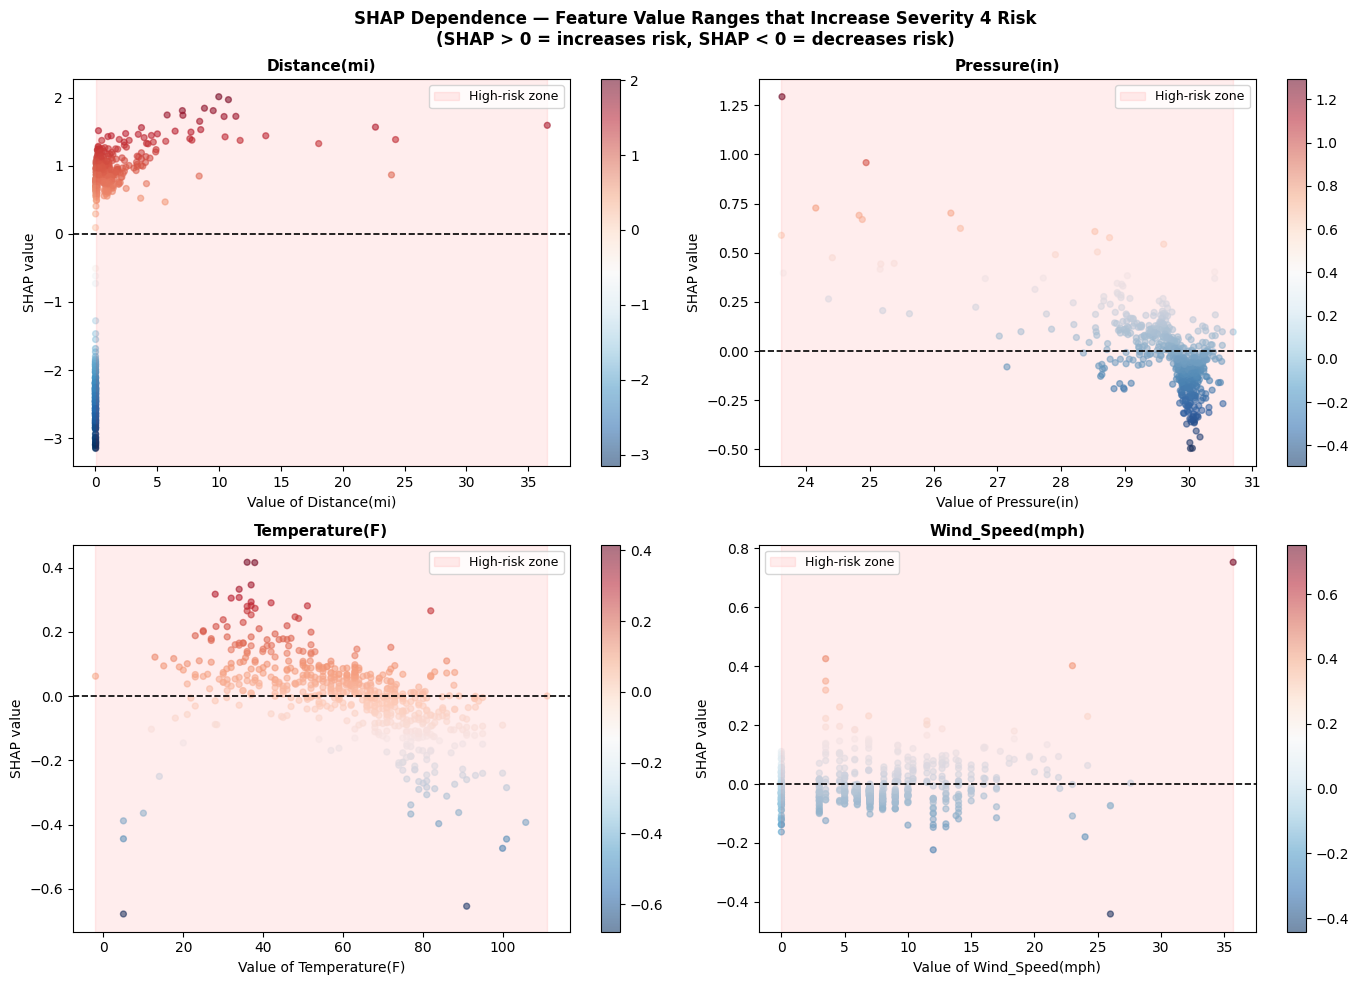

In [25]:
# ── Plot 3: Dependence — top 4 continuous features ────────────────────────────
top4_cont_idx = sorted(
    [i for i, f in enumerate(feature_names) if f in CONT_FEATS],
    key=lambda i: mean_abs[i], reverse=True
)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence — Feature Value Ranges that Increase Severity 4 Risk\n'
             '(SHAP > 0 = increases risk, SHAP < 0 = decreases risk)', fontsize=12, fontweight='bold')

for ax, fi in zip(axes.flatten(), top4_cont_idx):
    feat = feature_names[fi]
    sc = ax.scatter(X_shap[:, fi], sv[:, fi],
                    c=sv[:, fi], cmap='RdBu_r', alpha=0.55, s=18)
    ax.axhline(0, color='black', lw=1.2, ls='--')
    danger_mask = sv[:, fi] > 0
    if danger_mask.sum() > 5:
        dv = X_shap[danger_mask, fi]
        ax.axvspan(dv.min(), dv.max(), alpha=0.07, color='red', label='High-risk zone')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Value of {feat}', fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

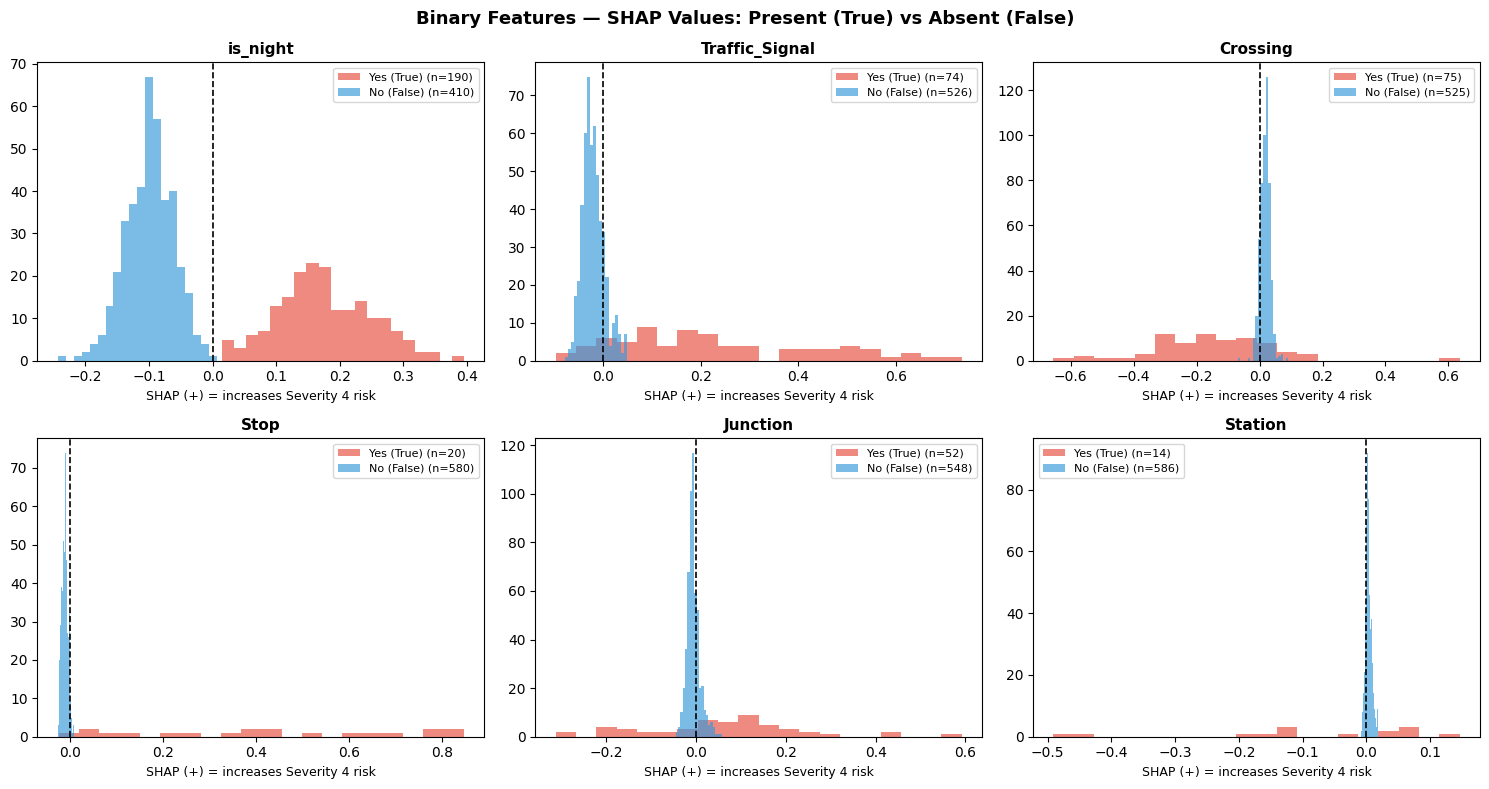


─────────────────────────────────────────────────────────────────
Feature                   Type         Increases Severity 4 risk when...
─────────────────────────────────────────────────────────────────
Distance(mi)              Continuous   Value between 0.00 and 36.53
Pressure(in)              Continuous   Value between 23.61 and 30.70
Temperature(F)            Continuous   Value between -2.00 and 111.20
Wind_Speed(mph)           Continuous   Value between 0.00 and 35.70
is_night                  Binary       When True (present) → SHAP=+0.1749
Traffic_Signal            Binary       When True (present) → SHAP=+0.2298
Crossing                  Binary       When False (absent) → SHAP=+0.0173
Stop                      Binary       When True (present) → SHAP=+0.4230
Junction                  Binary       When True (present) → SHAP=+0.0624
Station                   Binary       When False (absent) → SHAP=+0.0034
─────────────────────────────────────────────────────────────────


In [26]:
# ── Plot 4: Binary features — Present vs Absent ───────────────────────────────
top6_bool_idx = sorted(
    [i for i, f in enumerate(feature_names) if f in BOOL_FEATS],
    key=lambda i: mean_abs[i], reverse=True
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Binary Features — SHAP Values: Present (True) vs Absent (False)', fontsize=13, fontweight='bold')

for ax, fi in zip(axes.flatten(), top6_bool_idx):
    feat = feature_names[fi]
    for val, label, color in [(1, 'Yes (True)', '#e74c3c'), (0, 'No (False)', '#3498db')]:
        mask = X_shap[:, fi] == val
        if mask.sum() > 0:
            ax.hist(sv[mask, fi], bins=20, alpha=0.65, color=color,
                    label=f'{label} (n={mask.sum()})')
    ax.axvline(0, color='black', lw=1.2, ls='--')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP (+) = increases Severity 4 risk', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}sev4_shap_binary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────────
print('\n' + '─' * 65)
print(f'{"Feature":<25} {"Type":<12} {"Increases Severity 4 risk when..."}')
print('─' * 65)
for fi in top4_cont_idx:
    feat = feature_names[fi]
    dmask = sv[:, fi] > 0
    if dmask.sum() > 0:
        lo, hi = X_shap[dmask, fi].min(), X_shap[dmask, fi].max()
        print(f'{feat:<25} {"Continuous":<12} Value between {lo:.2f} and {hi:.2f}')
for fi in top6_bool_idx:
    feat = feature_names[fi]
    st = sv[X_shap[:, fi] == 1, fi].mean() if (X_shap[:, fi] == 1).sum() > 0 else 0
    sf = sv[X_shap[:, fi] == 0, fi].mean() if (X_shap[:, fi] == 0).sum() > 0 else 0
    danger_val = 'True (present)' if st > sf else 'False (absent)'
    print(f'{feat:<25} {"Binary":<12} When {danger_val} → SHAP={max(st, sf):+.4f}')
print('─' * 65)

# 9. LIME Explanation

Explain each specific case — why the model predicts an instance as Severity 4 or non-Severity 4.

In [27]:
cat_feat_idx = [feature_names.index(f) for f in feature_names
                if f in BOOL_FEATS or any(
                    f.startswith(c + '_') for c in ['Wind_Direction', 'Weather_Condition', 'Timezone']
                )]

class_names = ['Non-critical (Sev 1/2/3)', 'Severity 4']

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=class_names,
    categorical_features=cat_feat_idx,
    mode='classification',
    random_state=RANDOM_STATE,
)

def explain_and_plot(idx, title, save_name):
    instance   = X_test_np[idx]
    true_label = y_test[idx]
    pred_proba = lgb_model.predict_proba(instance.reshape(1, -1))[0]
    pred_label = int(np.argmax(pred_proba))

    exp = explainer_lime.explain_instance(
        data_row=instance,
        predict_fn=lgb_model.predict_proba,
        num_features=10,
        labels=[1],
    )

    print(f"\n{'─'*60}")
    print(f"  {title}")
    print(f"  Ground truth : {class_names[true_label]}")
    print(f"  Predicted    : {class_names[pred_label]}  (P(Sev4) = {pred_proba[1]:.3f})")
    correct = '✓ CORRECT' if true_label == pred_label else '✗ WRONG'
    print(f"  Result       : {correct}")
    print(f"{'─'*60}")
    print(f"  {'Condition / Feature':<38} {'Contribution':>12}  Direction")
    print(f"  {'─'*58}")
    for cond, weight in exp.as_list(label=1):
        arrow = '↑ increases Sev4 risk' if weight > 0 else '↓ decreases Sev4 risk'
        print(f"  {cond:<38} {weight:>+.4f}   {arrow}")

    fig = exp.as_pyplot_figure(label=1)
    plt.title(f'LIME — {title}\n'
              f'Predicted: {class_names[pred_label]} | P(Sev4)={pred_proba[1]:.3f}',
              fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}lime_{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('LIME explainer ready.')

LIME explainer ready.



────────────────────────────────────────────────────────────
  Critical Case — Correctly Predicted (Sev4 → Sev4)
  Ground truth : Severity 4
  Predicted    : Severity 4  (P(Sev4) = 0.877)
  Result       : ✓ CORRECT
────────────────────────────────────────────────────────────
  Condition / Feature                    Contribution  Direction
  ──────────────────────────────────────────────────────────
  Distance(mi) > 0.86                    +0.2096   ↑ increases Sev4 risk
  Timezone_US/Pacific=0                  +0.1447   ↑ increases Sev4 risk
  Bump=0                                 +0.1421   ↑ increases Sev4 risk
  Stop=0                                 -0.1163   ↓ decreases Sev4 risk
  Give_Way=0                             +0.1130   ↑ increases Sev4 risk
  Weather_Condition_Thunder in the Vicinity=0 -0.1087   ↓ decreases Sev4 risk
  Weather_Condition_Clear=0              -0.1011   ↓ decreases Sev4 risk
  Wind_Direction_Calm=0                  -0.0782   ↓ decreases Sev4 risk
  Statio

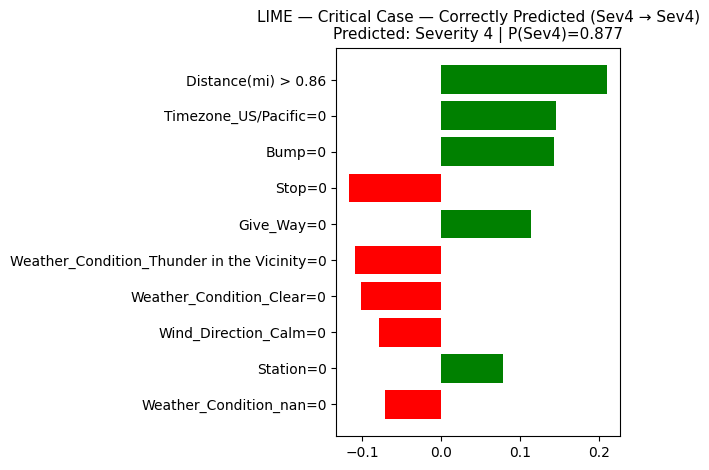

In [28]:
# ── Case 1: Severity 4 — correctly predicted ─────────────────────────────────
correct_pos = np.where((y_test == 1) & (lgb_model.predict(X_test_np) == 1))[0]
explain_and_plot(correct_pos[0], 'Critical Case — Correctly Predicted (Sev4 → Sev4)', 'case1_correct_sev4')


────────────────────────────────────────────────────────────
  Non-Critical Case — Correctly Predicted (Other → Other)
  Ground truth : Non-critical (Sev 1/2/3)
  Predicted    : Non-critical (Sev 1/2/3)  (P(Sev4) = 0.457)
  Result       : ✓ CORRECT
────────────────────────────────────────────────────────────
  Condition / Feature                    Contribution  Direction
  ──────────────────────────────────────────────────────────
  0.00 < Distance(mi) <= 0.20            +0.1859   ↑ increases Sev4 risk
  Timezone_nan=0                         +0.1633   ↑ increases Sev4 risk
  Timezone_US/Pacific=0                  +0.1396   ↑ increases Sev4 risk
  Traffic_Calming=0                      +0.1360   ↑ increases Sev4 risk
  Weather_Condition_Haze=0               -0.1311   ↓ decreases Sev4 risk
  Wind_Direction_Calm=0                  -0.1122   ↓ decreases Sev4 risk
  Weather_Condition_Clear=0              -0.1085   ↓ decreases Sev4 risk
  No_Exit=0                              -0.1025   ↓

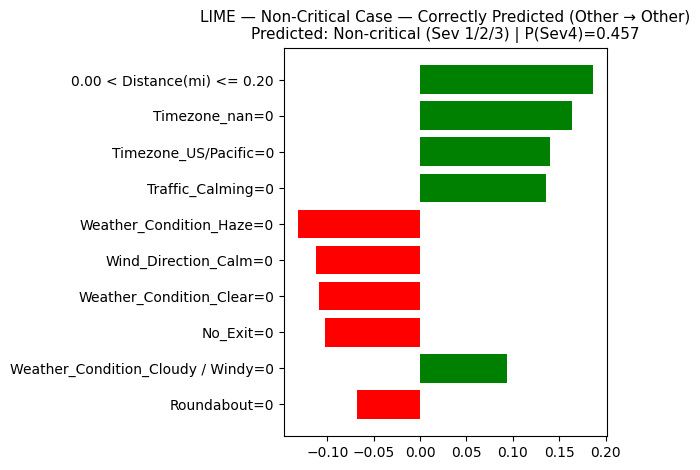

In [29]:
# ── Case 2: Non-critical — correctly predicted ────────────────────────────────
correct_neg = np.where((y_test == 0) & (lgb_model.predict(X_test_np) == 0))[0]
explain_and_plot(correct_neg[0], 'Non-Critical Case — Correctly Predicted (Other → Other)', 'case2_correct_neg')


────────────────────────────────────────────────────────────
  Missed Case: True Sev4 Predicted as Non-Critical (False Negative)
  Ground truth : Severity 4
  Predicted    : Non-critical (Sev 1/2/3)  (P(Sev4) = 0.368)
  Result       : ✗ WRONG
────────────────────────────────────────────────────────────
  Condition / Feature                    Contribution  Direction
  ──────────────────────────────────────────────────────────
  0.20 < Distance(mi) <= 0.86            +0.2603   ↑ increases Sev4 risk
  Timezone_US/Pacific=0                  +0.1430   ↑ increases Sev4 risk
  Timezone_nan=0                         +0.1288   ↑ increases Sev4 risk
  Weather_Condition_Light Drizzle=0      +0.1120   ↑ increases Sev4 risk
  Weather_Condition_Clear=0              -0.1101   ↓ decreases Sev4 risk
  Stop=0                                 -0.0937   ↓ decreases Sev4 risk
  Weather_Condition_nan=0                -0.0927   ↓ decreases Sev4 risk
  Traffic_Signal=0                       -0.0883   ↓ decre

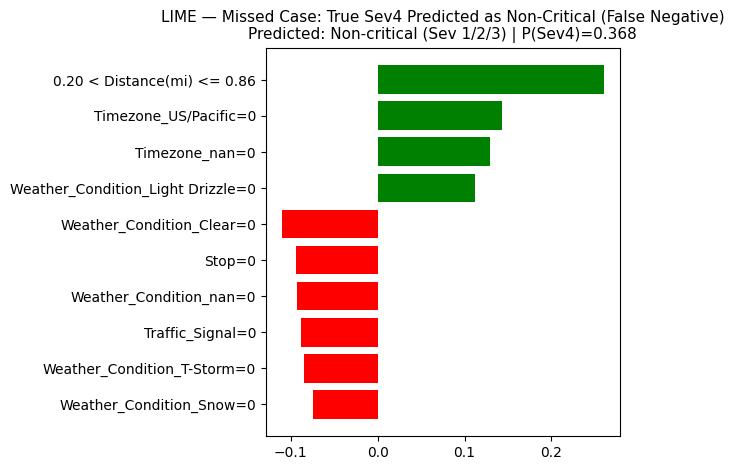


→ False Negative: model missed 3916 Severity 4 accidents.
  LIME analysis shows why the model lacked confidence in the Sev4 class for this instance.


In [30]:
# ── Case 3: Severity 4 predicted as Non-critical (most important error) ───────
# Model missed a critical accident — why?
wrong_sev4 = np.where((y_test == 1) & (lgb_model.predict(X_test_np) == 0))[0]
if len(wrong_sev4) > 0:
    explain_and_plot(wrong_sev4[0],
                     'Missed Case: True Sev4 Predicted as Non-Critical (False Negative)',
                     'case3_wrong_sev4')
    print(f'\n→ False Negative: model missed {len(wrong_sev4)} Severity 4 accidents.')
    print('  LIME analysis shows why the model lacked confidence in the Sev4 class for this instance.')
else:
    print('No False Negatives — model perfectly detected all Severity 4 on the test set!')

# 10. Cross-Validation (LightGBM)

5-fold stratified cross-validation is used to evaluate model stability beyond a single train/test split.

In [31]:
print('=' * 60)
print('5-FOLD STRATIFIED CV — LightGBM')
print('=' * 60)

X_cv = np.concatenate([X_train_np, X_val_np], axis=0)
y_cv = np.concatenate([y_train, y_val], axis=0)

skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_acc = []
cv_f1  = []
cv_auc = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    Xf_tr, Xf_val = X_cv[tr_idx], X_cv[val_idx]
    yf_tr, yf_val = y_cv[tr_idx], y_cv[val_idx]

    lgb_cv = lgb.LGBMClassifier(
        n_estimators=2000, num_leaves=63, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
    )
    lgb_cv.fit(
        Xf_tr, yf_tr,
        eval_set=[(Xf_val, yf_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    yf_pred  = lgb_cv.predict(Xf_val)
    yf_proba = lgb_cv.predict_proba(Xf_val)[:, 1]

    cv_acc.append(accuracy_score(yf_val, yf_pred))
    cv_f1.append(f1_score(yf_val, yf_pred, average='weighted'))
    cv_auc.append(roc_auc_score(yf_val, yf_proba))
    print(f'  Fold {fold+1}: Acc={cv_acc[-1]:.4f}  F1={cv_f1[-1]:.4f}  AUC={cv_auc[-1]:.4f}')

print(f'\nCV Accuracy : {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}')
print(f'CV F1 (wt.) : {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}')
print(f'CV AUC-ROC  : {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')

5-FOLD STRATIFIED CV — LightGBM
  Fold 1: Acc=0.7946  F1=0.7933  AUC=0.8659
  Fold 2: Acc=0.7955  F1=0.7943  AUC=0.8680
  Fold 3: Acc=0.7940  F1=0.7928  AUC=0.8661
  Fold 4: Acc=0.7976  F1=0.7964  AUC=0.8698
  Fold 5: Acc=0.7983  F1=0.7971  AUC=0.8707

CV Accuracy : 0.7960 ± 0.0017
CV F1 (wt.) : 0.7948 ± 0.0017
CV AUC-ROC  : 0.8681 ± 0.0019
